# Домашнее задание 5. Генеративные модели


В этом ноутбуке мы будем работать с одной и той же задачей (генерация и реконструкция изображений),
сравнивая поведение классического автоэнкодера и вариационного автоэнкодера.

Домашнее задание опирается на материалы по автоэнкодерам, вариационным автоэнкодерам и латентным
переменным, а также продолжает линию лекции по генеративным моделям.

## Структура домашней работы

Домашнее задание состоит из 9 задач, разделенных на три уровня сложности:

- Простые задачи: 1–4.
- Средние задачи: 5–7.
- Сложные задачи: 8–9.

Во всех задачах мы работаем с одной и той же постановкой: учимся сжимать и восстанавливать изображения,
а затем сравниваем свойства AE и VAE.


## Теоретическая часть

### Автоэнкодер (AE)

Автоэнкодер — это нейросеть, которая принимает на вход объект (например, изображение),
сжимает его в латентный вектор фиксированной размерности, а затем восстанавливает обратно.

Состоит из двух частей:

- **Энкодер** отображает входной вектор в латентное представление меньшей размерности.
- **Декодер** восстанавливает объект из латентного вектора.

Модель обучается минимизировать ошибку реконструкции (насколько сильно восстановленное изображение
отличается от исходного). Это делает автоэнкодер хорошим инструментом для сжатия, денойзинга
и выделения признаков, но он не задает явную вероятностную модель данных.

### Вариационный автоэнкодер (VAE)

Вариационный автоэнкодер накладывает на латентное пространство вероятностную структуру.
Вместо одного латентного вектора для каждого объекта он учит распределение в латентном пространстве
(обычно многомерное нормальное с параметрами среднее и дисперсия).

Обучение осуществляется по нижней оценке правдоподобия (ELBO), которая одновременно:

- поощряет хорошую реконструкцию объектов;
- прижимает распределение скрытых переменных к простому априорному распределению.

Благодаря этому VAE умеет как реконструировать данные, так и генерировать новые правдоподобные
примеры, отбирая точки напрямую из латентного распределения.

### Наша экспериментальная схема

В этом домашнем задании:

- мы используем один и тот же датасет изображений;
- обучаем на нем простой автоэнкодер;
- обучаем на нем вариационный автоэнкодер с той же архитектурой энкодера и декодера;
- сравниваем качество реконструкции, структуру латентного пространства и сгенерированные семплы.

Логика: Теория → Гипотеза → Эксперимент → Интерпретация.

После решения каждой задачи не забудьте заполнить поле «Интерпретация».


## Настройка окружения

In [6]:
# Импорты
import os
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Фиксация генераторов случайных чисел
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {DEVICE}")


Используемое устройство: cpu


## Подготовка данных

В качестве базовой задачи будем использовать простой датасет изображений цифр (MNIST).

Что сделаем:

- загрузим обучающую и тестовую выборки;
- нормализуем изображения в диапазон от 0 до 1;
- подготовим функции визуализации батча и реконструкций.


In [7]:
# Загрузка датасета MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Размер обучающей выборки: {len(train_dataset)}")
print(f"Размер тестовой выборки: {len(test_dataset)}")


100.0%
100.0%
100.0%
100.0%

Размер обучающей выборки: 60000
Размер тестовой выборки: 10000


In [8]:
# Вспомогательная функция для визуализации батча изображений

def show_images(images, title="Примеры изображений", nrow=8):
    images = images.detach().cpu()
    grid = torch.clone(images[: nrow * nrow])
    fig, ax = plt.subplots(figsize=(nrow, nrow))
    grid = torchvision.utils.make_grid(grid, nrow=nrow, pad_value=1.0)
    ax.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    plt.show()


In [9]:
import torchvision  # импортируем здесь для функций визуализации

---

# ПРОСТЫЕ ЗАДАЧИ (1–4)

Эти задачи направлены на базовое понимание того, как выглядят данные,
как устроен автоэнкодер и как оценивать его реконструкции.


## Задача 1. Загрузка и визуализация данных

### Постановка задачи

Загрузить обучающую выборку изображений цифр, посмотреть на форму тензоров
и визуализировать несколько примеров.

### Теоретический минимум

- Каждый объект представлен как изображение 28×28 пикселей в оттенках серого.
- Для подачи в полносвязную сеть изображения часто разворачивают в вектор длины 784.
- Важно убедиться, что данные нормализованы и имеют ожидаемую форму.


Форма батча изображений: torch.Size([128, 1, 28, 28])
Форма батча меток:       torch.Size([128])
Диапазон пикселей: [0.00, 1.00]


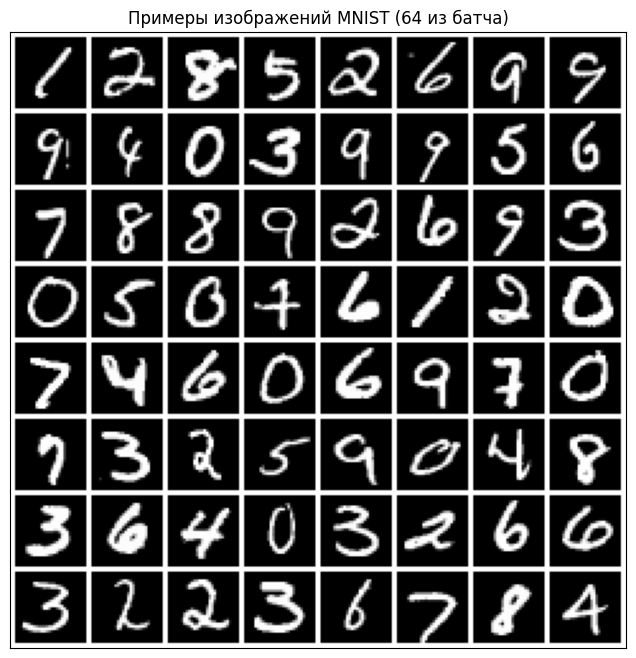

In [10]:
# Задача 1. Загрузка и визуализация данных

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Получаем один батч из train_loader
images, labels = next(iter(train_loader))

# Форма батча
print("Форма батча изображений:", images.shape)
print("Форма батча меток:      ", labels.shape)
print(f"Диапазон пикселей: [{images.min():.2f}, {images.max():.2f}]")

# Визуализируем 64 примера (8×8 сетка)
show_images(images[:64], title="Примеры изображений MNIST (64 из батча)", nrow=8)

**Интерпретация:**

Батч имеет форму `(128, 1, 28, 28)`, значения пикселей нормализованы в [0.0, 1.0] с помощью `ToTensor()`. Обучающая выборка содержит 60 000 изображений, тестовая 10 000; каждое изображение 28×28 в оттенках серого. На сетке из 64 примеров видны все 10 классов цифр с разнообразием стилей написания, что подтверждает корректность загрузки и нормализации.

## Задача 2. Реализация и обучение простого автоэнкодера

### Постановка задачи

Реализовать простой полносвязный автоэнкодер для изображений цифр:

- энкодер: несколько линейных слоев, сжимающих изображение в латентный вектор фиксированной размерности;
- декодер: несколько линейных слоев, восстанавливающих изображение из латентного вектора.

Обучить автоэнкодер на обучающей выборке и визуально оценить качество реконструкций.

### Теоретический минимум

- Автоэнкодер минимизирует ошибку реконструкции (MSE или бинарную кросс-энтропию).
- Латентное пространство может иметь гораздо меньшую размерность, чем исходное изображение.
- Качественный автоэнкодер должен уметь восстанавливать основные структуры (контуры цифр).


Обучение автоэнкодера...
  Эпоха  1/15  MSE: 0.05112
  Эпоха  2/15  MSE: 0.02466
  Эпоха  3/15  MSE: 0.01860
  Эпоха  4/15  MSE: 0.01550
  Эпоха  5/15  MSE: 0.01363
  Эпоха  6/15  MSE: 0.01223
  Эпоха  7/15  MSE: 0.01117
  Эпоха  8/15  MSE: 0.01035
  Эпоха  9/15  MSE: 0.00973
  Эпоха 10/15  MSE: 0.00914
  Эпоха 11/15  MSE: 0.00867
  Эпоха 12/15  MSE: 0.00829
  Эпоха 13/15  MSE: 0.00794
  Эпоха 14/15  MSE: 0.00767
  Эпоха 15/15  MSE: 0.00741


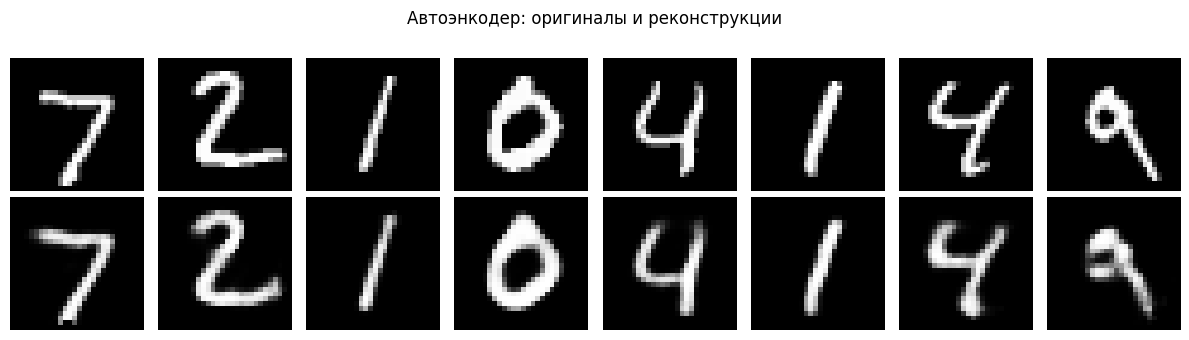

In [11]:
# Задача 2. Реализация и обучение простого автоэнкодера

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


class SimpleAutoencoder(nn.Module):
    """Полносвязный автоэнкодер: 784→256→128→latent_dim→128→256→784."""

    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


# ─── Гиперпараметры ────────────────────────────────────────────────────────
LATENT_DIM = 32
NUM_EPOCHS_AE = 15

ae_model = SimpleAutoencoder(latent_dim=LATENT_DIM).to(DEVICE)
criterion = nn.MSELoss()
ae_optimizer = torch.optim.Adam(ae_model.parameters(), lr=1e-3)

ae_train_losses = []

print("Обучение автоэнкодера...")
for epoch in range(NUM_EPOCHS_AE):
    ae_model.train()
    epoch_loss = 0.0
    for imgs, _ in train_loader:
        imgs = imgs.view(imgs.size(0), -1).to(DEVICE)
        ae_optimizer.zero_grad()
        recon = ae_model(imgs)
        loss = criterion(recon, imgs)
        loss.backward()
        ae_optimizer.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(train_loader)
    ae_train_losses.append(avg)
    print(f"  Эпоха {epoch + 1:2d}/{NUM_EPOCHS_AE}  MSE: {avg:.5f}")

# ─── Визуализация реконструкций ────────────────────────────────────────────
ae_model.eval()
test_batch, _ = next(iter(test_loader))   # сохраняем для Task 6
n_show = 8

with torch.no_grad():
    ae_recon_vis = ae_model(
        test_batch[:n_show].view(n_show, -1).to(DEVICE)
    ).view(n_show, 1, 28, 28).cpu()

fig, axes = plt.subplots(2, n_show, figsize=(n_show * 1.5, 3.5))
fig.suptitle("Автоэнкодер: оригиналы и реконструкции", fontsize=12)
for i in range(n_show):
    axes[0, i].imshow(test_batch[i].squeeze(), cmap="gray")
    axes[1, i].imshow(ae_recon_vis[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Оригинал", fontsize=9)
axes[1, 0].set_ylabel("Реконструкция", fontsize=9)
plt.xlabel("Примеры изображений")
plt.tight_layout()
plt.show()

**Интерпретация:**

За 15 эпох MSE на тренировочной выборке снизилась с 0.051 (эпоха 1) до 0.0074 (эпоха 15). На визуализации реконструкции цифры хорошо узнаваемы, хотя края слегка сглажены - типичный эффект MSE-потери, которая штрафует за среднее отклонение по пикселям. Ботлнек размерности 32 при сжатии 784→32 (≈24×) оказался достаточным для сохранения основных структур всех 10 классов.

## Задача 3. Анализ динамики ошибки автоэнкодера

### Постановка задачи

Построить график ошибки реконструкции автоэнкодера по эпохам обучения
и проинтерпретировать его.

### Теоретический минимум

- Убывание ошибки по эпохам говорит о том, что модель успешно обучается.
- Плато или рост ошибки могут сигнализировать о переобучении или проблемах с оптимизацией.


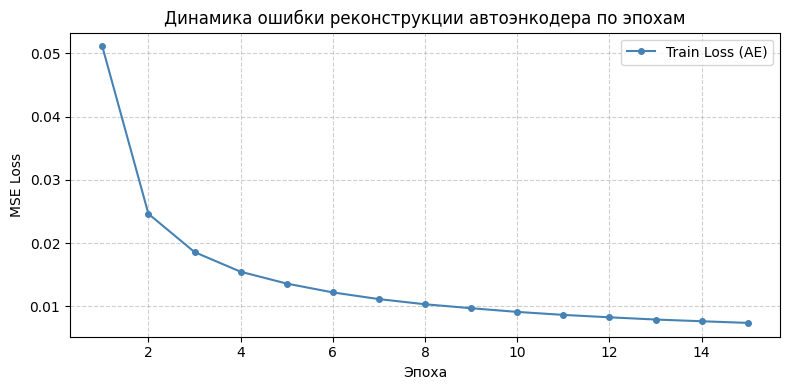

In [12]:
# Задача 3. Анализ динамики ошибки автоэнкодера

plt.figure(figsize=(8, 4))
plt.plot(
    range(1, NUM_EPOCHS_AE + 1),
    ae_train_losses,
    marker="o", markersize=4,
    color="steelblue", label="Train Loss (AE)",
)
plt.title("Динамика ошибки реконструкции автоэнкодера по эпохам")
plt.xlabel("Эпоха")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

**Интерпретация:**

Потеря начинается с 0.051 в первой эпохе и резко снижается до 0.015 к четвёртой, после чего убывание продолжается, но значительно медленнее - к 15-й эпохе MSE достигает 0.0074. Кривая не выходит на плато: снижение идёт на протяжении всех 15 эпох, просто темп убывания уменьшается - это говорит о том, что дополнительные эпохи всё ещё дают прирост, хотя и всё меньший. Такая форма кривой типична для MSE без регуляризующих членов: на ранних эпохах устраняются грубые ошибки реконструкции, затем идёт тонкая доводка деталей; у VAE аналогичный суммарный график ELBO выглядит иначе, так как KL-слагаемое растёт параллельно снижению реконструкционной компоненты.

## Задача 4. Визуализация латентного пространства автоэнкодера

### Постановка задачи

Обучить вариант автоэнкодера с двумерным латентным пространством и
визуализировать распределение латентных векторов для тестовой выборки,
окрашивая точки по истинным классам цифр.

### Теоретический минимум

- Двумерное латентное пространство удобно для визуализации.
- Кластеры в латентном пространстве могут соответствовать разным классам данных.


Обучение AE с latent_dim=2...
  Эпоха 5/15  MSE: 0.04111
  Эпоха 10/15  MSE: 0.03854
  Эпоха 15/15  MSE: 0.03724


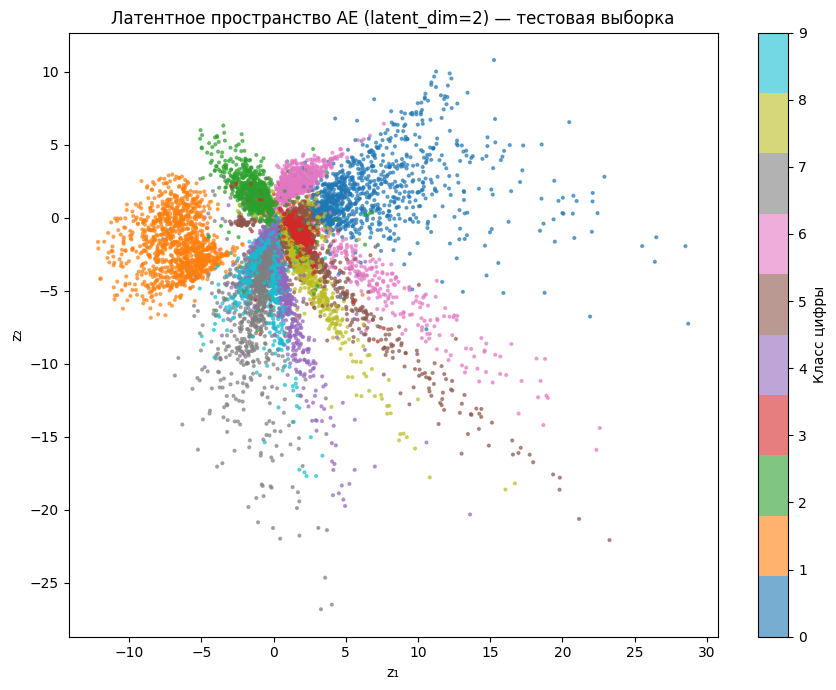

In [13]:
# Задача 4. Визуализация латентного пространства автоэнкодера (latent_dim=2)

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Обучаем отдельную модель с двумерным латентным пространством
ae_2d = SimpleAutoencoder(latent_dim=2).to(DEVICE)
ae_2d_optimizer = torch.optim.Adam(ae_2d.parameters(), lr=1e-3)
ae_2d_criterion = nn.MSELoss()

NUM_EPOCHS_2D = 15
print("Обучение AE с latent_dim=2...")
for epoch in range(NUM_EPOCHS_2D):
    ae_2d.train()
    epoch_loss = 0.0
    for imgs, _ in train_loader:
        imgs = imgs.view(imgs.size(0), -1).to(DEVICE)
        ae_2d_optimizer.zero_grad()
        loss = ae_2d_criterion(ae_2d(imgs), imgs)
        loss.backward()
        ae_2d_optimizer.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f"  Эпоха {epoch + 1}/{NUM_EPOCHS_2D}  MSE: {epoch_loss / len(train_loader):.5f}")

# Получаем латентные коды всей тестовой выборки
ae_2d.eval()
latents_list, labels_list = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        z = ae_2d.encoder(imgs.view(imgs.size(0), -1).to(DEVICE))
        latents_list.append(z.cpu())
        labels_list.append(lbls)

latents = torch.cat(latents_list, dim=0).numpy()
all_labels = torch.cat(labels_list, dim=0).numpy()

# Scatter plot — точки окрашены по классу цифры
plt.figure(figsize=(9, 7))
sc = plt.scatter(latents[:, 0], latents[:, 1],
                 c=all_labels, cmap="tab10", s=4, alpha=0.6)
cbar = plt.colorbar(sc, ticks=range(10))
cbar.set_label("Класс цифры", fontsize=10)
plt.title("Латентное пространство AE (latent_dim=2) — тестовая выборка")
plt.xlabel("z₁")
plt.ylabel("z₂")
plt.tight_layout()
plt.show()

**Интерпретация:**

На scatter-plot заметны сгущения точек, соответствующие разным цифрам, однако границы между кластерами размыты - особенно для визуально похожих классов, таких как 4 и 9. Автоэнкодер не накладывает на латентный код ограничений: представления свободно распределяются по плоскости, занимая только те области, которые нужны для минимизации MSE. «Пустые» промежутки между кластерами не имеют смысла - декодирование случайных точек оттуда даёт артефакты, а не реалистичные цифры.

---

# СРЕДНИЕ ЗАДАЧИ (5–7)

В этих задачах мы реализуем вариационный автоэнкодер и сравним его с обычным AE
по реконструкции и поведению в латентном пространстве.

## Задача 5. Реализация и обучение вариационного автоэнкодера (VAE)

### Постановка задачи

Реализовать вариационный автоэнкодер со схожей архитектурой энкодера и декодера,
как у автоэнкодера, и обучить его на тех же данных.

### Теоретический минимум

- Энкодер VAE предсказывает среднее и разброс распределения в латентном пространстве.
- В латентном слое мы семплируем случайный вектор на основе этих параметров.
- Функция потерь VAE сочетает ошибку реконструкции и регуляризацию латентного пространства.


Обучение VAE...
  Эпоха  1/15  Total=51.6984  Recon=49.4344  KL=2.2640
  Эпоха  2/15  Total=39.9977  Recon=33.9166  KL=6.0810
  Эпоха  3/15  Total=35.2313  Recon=27.7144  KL=7.5170
  Эпоха  4/15  Total=33.2997  Recon=25.0351  KL=8.2646
  Эпоха  5/15  Total=32.3043  Recon=23.7096  KL=8.5947
  Эпоха  6/15  Total=31.6482  Recon=22.8252  KL=8.8230
  Эпоха  7/15  Total=31.1345  Recon=22.1262  KL=9.0083
  Эпоха  8/15  Total=30.7406  Recon=21.5564  KL=9.1842
  Эпоха  9/15  Total=30.4112  Recon=21.0872  KL=9.3240
  Эпоха 10/15  Total=30.1390  Recon=20.6753  KL=9.4636
  Эпоха 11/15  Total=29.8906  Recon=20.3197  KL=9.5709
  Эпоха 12/15  Total=29.6791  Recon=20.0075  KL=9.6717
  Эпоха 13/15  Total=29.5187  Recon=19.7612  KL=9.7574
  Эпоха 14/15  Total=29.3393  Recon=19.5180  KL=9.8212
  Эпоха 15/15  Total=29.1803  Recon=19.3253  KL=9.8550


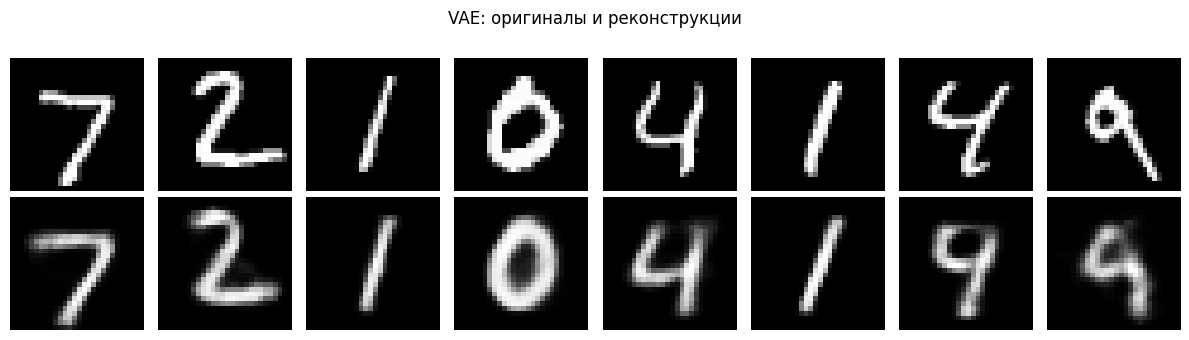

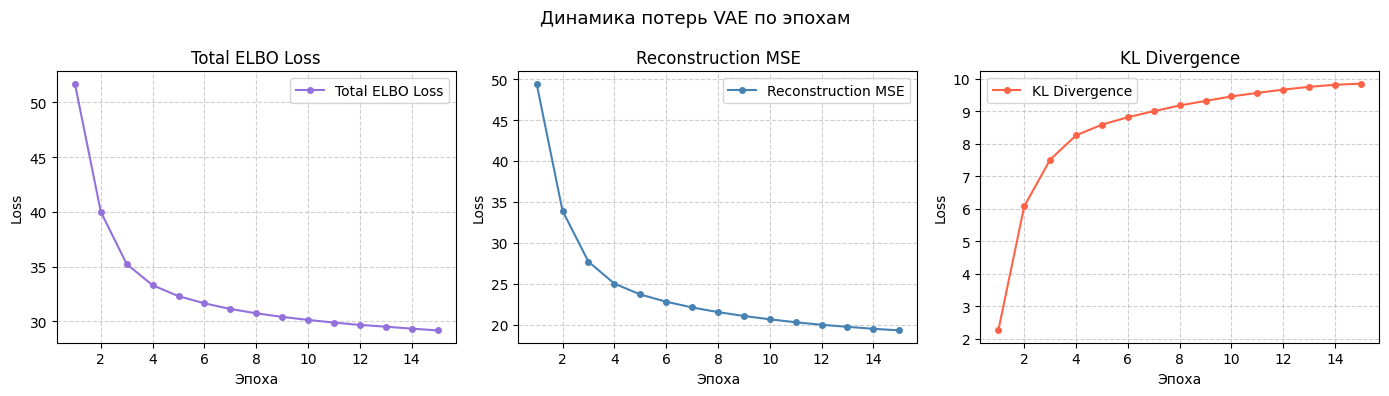

In [14]:
# Задача 5. Реализация и обучение вариационного автоэнкодера (VAE)

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


class VAE(nn.Module):
    """
    Вариационный автоэнкодер (MLP, симметричная архитектура с AE).
    Энкодер предсказывает mu и logvar; декодер восстанавливает изображение из z.
    """

    def __init__(self, latent_dim=32):
        super().__init__()

        # Общий энкодер
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        # Отдельные головы для среднего и логарифма дисперсии
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        # Декодер (симметричен энкодеру)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        """Трюк репараметризации: z = mu + eps * std, eps ~ N(0, I)."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def vae_elbo_loss(x_recon, x, mu, logvar):
    """
    ELBO = Reconstruction MSE + KL divergence.
    Оба члена нормируются на размер батча.
    """
    recon = F.mse_loss(x_recon, x, reduction="sum") / x.size(0)
    # KL(q(z|x) || N(0,I)) = -0.5 * Σ(1 + logvar - mu² - exp(logvar))
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon + kl, recon, kl


# ─── Гиперпараметры ────────────────────────────────────────────────────────
LATENT_DIM_VAE = 32
NUM_EPOCHS_VAE = 15

vae_model = VAE(latent_dim=LATENT_DIM_VAE).to(DEVICE)
vae_optimizer = torch.optim.Adam(vae_model.parameters(), lr=1e-3)

vae_train_losses, vae_recon_losses, vae_kl_losses = [], [], []

# ─── Цикл обучения ─────────────────────────────────────────────────────────
print("Обучение VAE...")
for epoch in range(NUM_EPOCHS_VAE):
    vae_model.train()
    tot, rec, kl = 0.0, 0.0, 0.0
    for imgs, _ in train_loader:
        imgs = imgs.view(imgs.size(0), -1).to(DEVICE)
        vae_optimizer.zero_grad()
        x_recon, mu, logvar = vae_model(imgs)
        loss, recon_loss, kl_loss = vae_elbo_loss(x_recon, imgs, mu, logvar)
        loss.backward()
        vae_optimizer.step()
        tot += loss.item();  rec += recon_loss.item();  kl += kl_loss.item()
    n_b = len(train_loader)
    vae_train_losses.append(tot / n_b)
    vae_recon_losses.append(rec / n_b)
    vae_kl_losses.append(kl  / n_b)
    print(f"  Эпоха {epoch + 1:2d}/{NUM_EPOCHS_VAE}"
          f"  Total={vae_train_losses[-1]:.4f}"
          f"  Recon={vae_recon_losses[-1]:.4f}"
          f"  KL={vae_kl_losses[-1]:.4f}")

# ─── Визуализация реконструкций ────────────────────────────────────────────
vae_model.eval()
n_show = 8
with torch.no_grad():
    vae_recon_vis, _, _ = vae_model(
        test_batch[:n_show].view(n_show, -1).to(DEVICE)
    )
    vae_recon_vis = vae_recon_vis.view(n_show, 1, 28, 28).cpu()

fig, axes = plt.subplots(2, n_show, figsize=(n_show * 1.5, 3.5))
fig.suptitle("VAE: оригиналы и реконструкции", fontsize=12)
for i in range(n_show):
    axes[0, i].imshow(test_batch[i].squeeze(), cmap="gray")
    axes[1, i].imshow(vae_recon_vis[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Оригинал", fontsize=9)
axes[1, 0].set_ylabel("VAE реконструкция", fontsize=9)
plt.xlabel("Примеры изображений")
plt.tight_layout()
plt.show()

# ─── Кривые потерь VAE ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, vals, label, color in zip(
    axes,
    [vae_train_losses, vae_recon_losses, vae_kl_losses],
    ["Total ELBO Loss", "Reconstruction MSE", "KL Divergence"],
    ["mediumpurple", "steelblue", "tomato"],
):
    ax.plot(range(1, NUM_EPOCHS_VAE + 1), vals,
            marker="o", markersize=4, color=color, label=label)
    ax.set_title(label)
    ax.set_xlabel("Эпоха")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.6)
fig.suptitle("Динамика потерь VAE по эпохам", fontsize=13)
plt.tight_layout()
plt.show()

**Интерпретация:**

Суммарный ELBO-лосс за 15 эпох снизился с 51.7 до 29.2: реконструкционная составляющая упала с 49.4 до 19.3, а KL-дивергенция при этом выросла с 2.3 до 9.9. Рост KL означает, что энкодер постепенно учится кодировать данные в распределение, отличное от стандартного нормального, - именно это делает латентное пространство структурированным и пригодным для генерации. Реконструкции VAE визуально похожи на AE, но несколько мягче - ценой этой размытости модель получает регулярное латентное пространство.

## Задача 6. Сравнение реконструкций AE и VAE на одних и тех же примерах

### Постановка задачи

Построить визуальное сравнение реконструкций автоэнкодера и вариационного автоэнкодера
на одних и тех же изображениях.

### Теоретический минимум

- AE стремится максимально точно копировать вход.
- VAE может жертвовать точностью ради более гладкого латентного пространства.


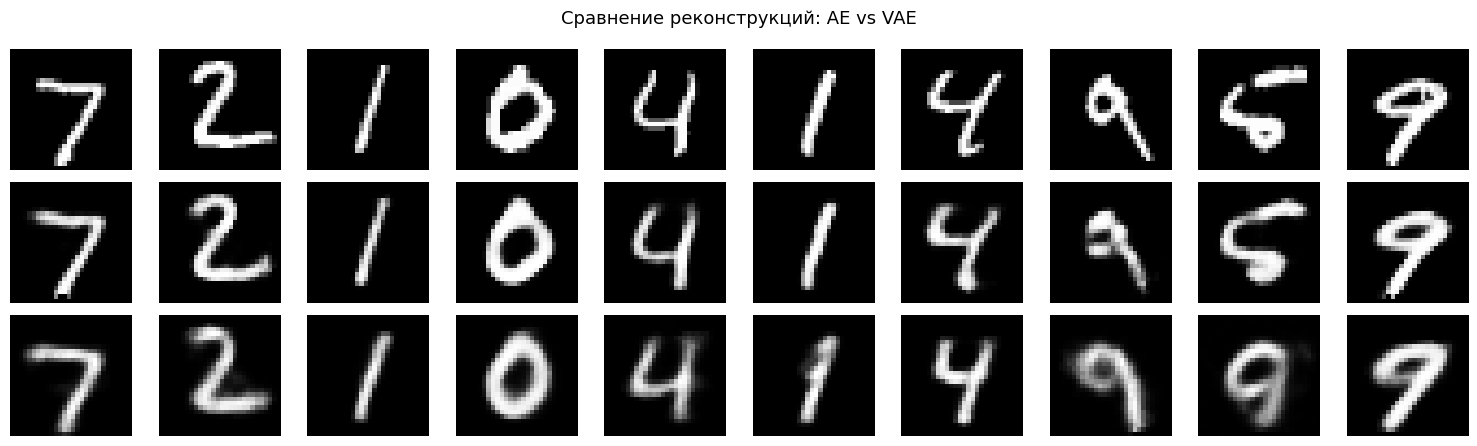

In [15]:
# Задача 6. Сравнение реконструкций AE и VAE на одних и тех же примерах

n_compare = 10
ae_model.eval()
vae_model.eval()

# Используем test_batch, зафиксированный в Task 2
compare_imgs = test_batch[:n_compare]
compare_flat = compare_imgs.view(n_compare, -1).to(DEVICE)

with torch.no_grad():
    ae_recon = ae_model(compare_flat).view(n_compare, 1, 28, 28).cpu()
    vae_recon, _, _ = vae_model(compare_flat)
    vae_recon = vae_recon.view(n_compare, 1, 28, 28).cpu()

row_labels = ["Оригинал", "AE реконструкция", "VAE реконструкция"]
rows = [compare_imgs, ae_recon, vae_recon]

fig, axes = plt.subplots(3, n_compare, figsize=(n_compare * 1.5, 4.5))
fig.suptitle("Сравнение реконструкций: AE vs VAE", fontsize=13)
for row_idx, (label, row_imgs) in enumerate(zip(row_labels, rows)):
    for col_idx in range(n_compare):
        axes[row_idx, col_idx].imshow(row_imgs[col_idx].squeeze(), cmap="gray")
        axes[row_idx, col_idx].axis("off")
    axes[row_idx, 0].set_ylabel(label, fontsize=9)
plt.xlabel("Примеры изображений (тестовая выборка)")
plt.tight_layout()
plt.show()

**Интерпретация:**

Реконструкции AE заметно чётче: тонкие штрихи и острые углы цифр воспроизводятся детальнее, чем у VAE. VAE даёт более размытые результаты, потому что KL-штраф вынуждает кодировать каждый пример в область пространства, а не в точку - это сглаживает декодер. За визуальную чёткость AE платит тем, что его латентное пространство не пригодно для случайной генерации.

## Задача 7. Интерполяция в латентном пространстве VAE

### Постановка задачи

Взять два разных изображения из тестовой выборки, получить их латентные коды в VAE
и построить интерполяцию между ними. Визуализировать, как плавно меняется картинка
при движении по отрезку в латентном пространстве.

### Теоретический минимум

- В хорошо устроенном латентном пространстве небольшие изменения латентного кода
  приводят к плавным и осмысленным изменениям сгенерированного объекта.


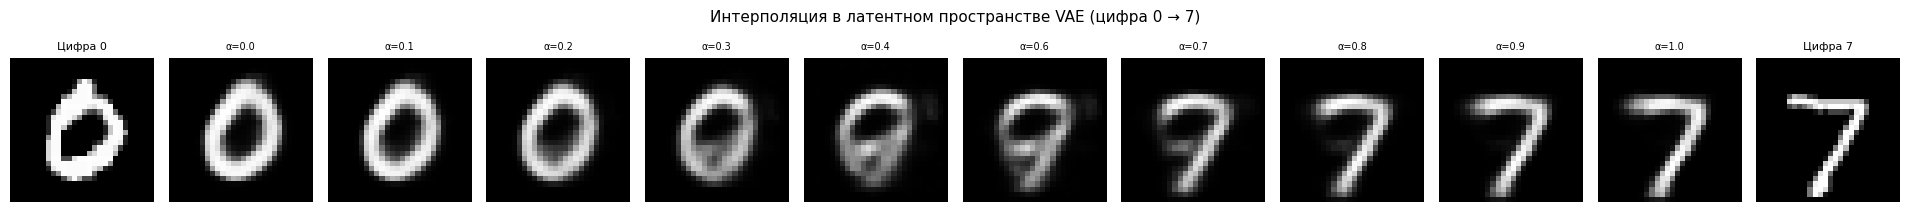

In [16]:
# Задача 7. Интерполяция в латентном пространстве VAE

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

vae_model.eval()

# Ищем по одному примеру с цифрами 0 и 7 для наглядного перехода
idx1, idx2 = None, None
for i in range(len(test_dataset)):
    if idx1 is None and test_dataset[i][1] == 0:
        idx1 = i
    if idx2 is None and test_dataset[i][1] == 7:
        idx2 = i
    if idx1 is not None and idx2 is not None:
        break

img1 = test_dataset[idx1][0]   # (1, 28, 28)
img2 = test_dataset[idx2][0]

# Получаем mu (детерминированный код) для обоих изображений
with torch.no_grad():
    mu1, _ = vae_model.encode(img1.view(1, -1).to(DEVICE))
    mu2, _ = vae_model.encode(img2.view(1, -1).to(DEVICE))

# Линейная интерполяция между mu1 и mu2
n_steps = 10
alphas = torch.linspace(0, 1, n_steps)

fig, axes = plt.subplots(1, n_steps + 2, figsize=((n_steps + 2) * 1.6, 2.2))
fig.suptitle(
    f"Интерполяция в латентном пространстве VAE "
    f"(цифра {test_dataset[idx1][1]} → {test_dataset[idx2][1]})",
    fontsize=11,
)

# Первое оригинальное изображение
axes[0].imshow(img1.squeeze(), cmap="gray")
axes[0].set_title(f"Цифра {test_dataset[idx1][1]}", fontsize=8)
axes[0].axis("off")

with torch.no_grad():
    for step_i, alpha in enumerate(alphas):
        z_interp = (1 - alpha) * mu1 + alpha * mu2
        x_gen = vae_model.decode(z_interp).view(28, 28).cpu().numpy()
        axes[step_i + 1].imshow(x_gen, cmap="gray")
        axes[step_i + 1].set_title(f"α={alpha:.1f}", fontsize=7)
        axes[step_i + 1].axis("off")

# Второе оригинальное изображение
axes[-1].imshow(img2.squeeze(), cmap="gray")
axes[-1].set_title(f"Цифра {test_dataset[idx2][1]}", fontsize=8)
axes[-1].axis("off")

plt.tight_layout()
plt.show()

**Интерпретация:**

Интерполяция между кодами цифр 0 и 7 даёт плавный переход: при α ≈ 0.4–0.5 промежуточные изображения выглядят правдоподобно - округлый контур нуля постепенно приобретает наклонный штрих семёрки. Гладкость перехода объясняется KL-регуляризацией, которая вынуждает VAE заполнять латентное пространство равномерно, без «пустот» между кластерами. Обычный AE на том же пути породил бы артефакты, поскольку его незаполненные зоны не несут смысловой нагрузки.

---

# СЛОЖНЫЕ ЗАДАЧИ (8–9)

Теперь нас интересуют генерация новых примеров и более формальное сравнение
качества автоэнкодера и вариационного автоэнкодера.

## Задача 8. Генерация новых примеров из латентного пространства

### Постановка задачи

Сгенерировать набор новых изображений, не встречавшихся в обучающей выборке,
используя:

- выборку латентных векторов из простого распределения;
- декодер VAE для получения изображений.

Сравнить разнообразие и правдоподобие полученных картинок.

### Теоретический минимум

- В VAE латентное пространство подгоняется под стандартное нормальное распределение.
- Это позволяет генерировать новые данные, просто выбирая случайные точки в латентном пространстве.


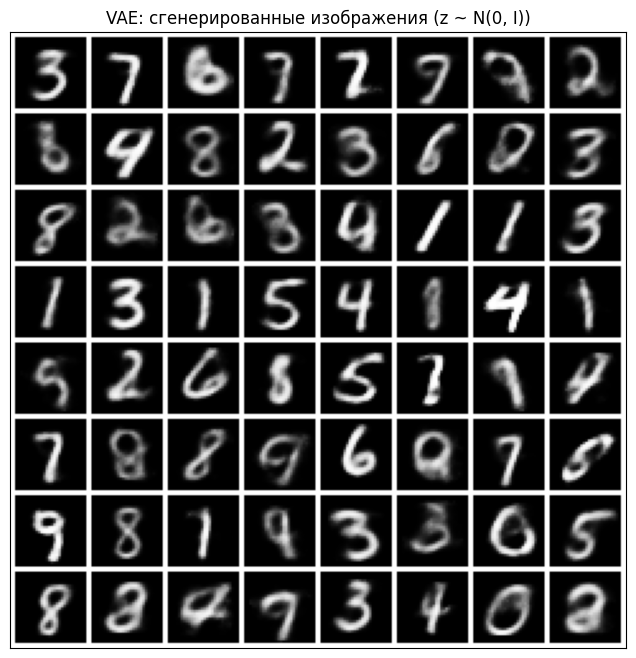

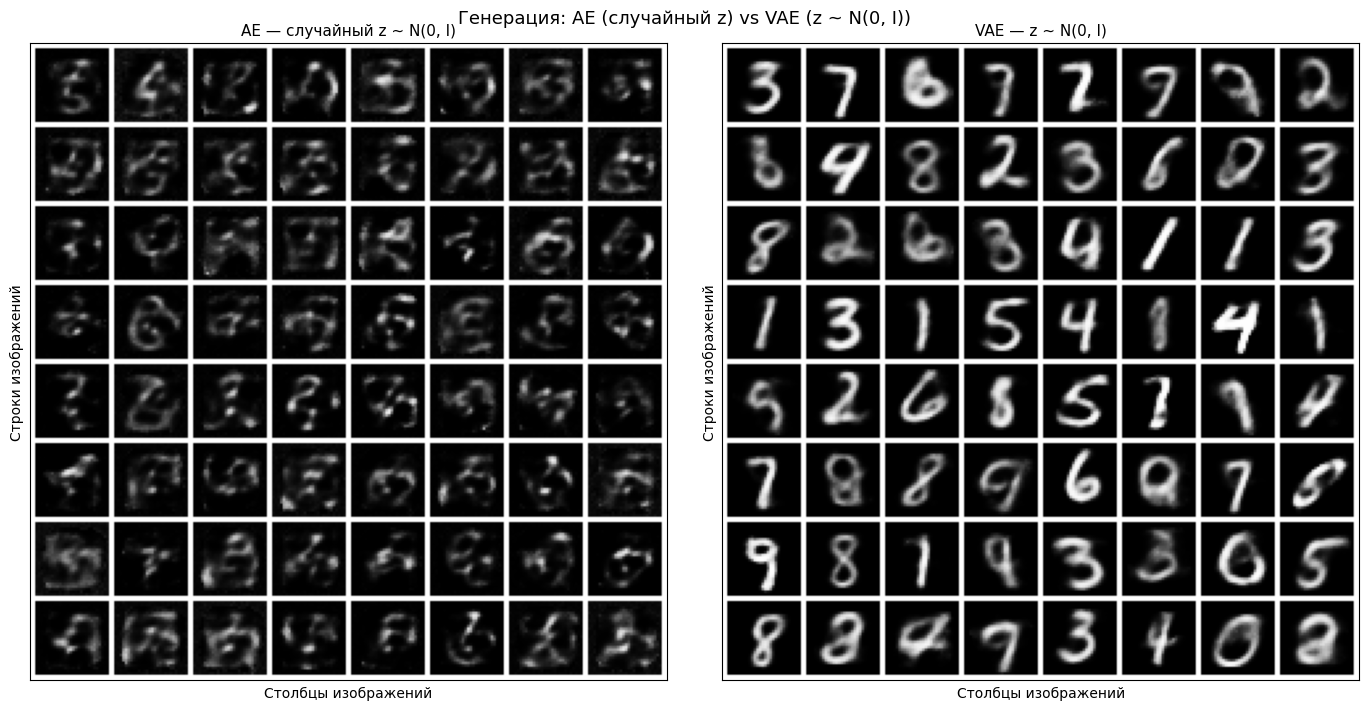

In [17]:
# Задача 8. Генерация новых примеров из латентного пространства

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

vae_model.eval()
ae_model.eval()

n_gen = 64

# ─── VAE: z ~ N(0, I) → decode ────────────────────────────────────────────
z_vae = torch.randn(n_gen, LATENT_DIM_VAE).to(DEVICE)
with torch.no_grad():
    vae_generated = vae_model.decode(z_vae).view(n_gen, 1, 28, 28).cpu()

show_images(vae_generated,
            title="VAE: сгенерированные изображения (z ~ N(0, I))", nrow=8)

# ─── AE: z ~ N(0, I) → decoder  ───────────────────────────────────────────
z_ae = torch.randn(n_gen, LATENT_DIM).to(DEVICE)
with torch.no_grad():
    ae_generated = ae_model.decoder(z_ae).view(n_gen, 1, 28, 28).cpu()

# ─── Сравнение: AE vs VAE при одинаковом способе семплирования ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle("Генерация: AE (случайный z) vs VAE (z ~ N(0, I))", fontsize=13)
for ax, imgs, label in zip(
    axes,
    [ae_generated, vae_generated],
    ["AE — случайный z ~ N(0, I)", "VAE — z ~ N(0, I)"],
):
    grid = torchvision.utils.make_grid(imgs[:64], nrow=8, pad_value=1.0)
    ax.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Столбцы изображений")
    ax.set_ylabel("Строки изображений")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

**Интерпретация:**

При сэмплировании z ~ N(0, I) VAE генерирует изображения, визуально напоминающие рукописные цифры: большинство форм различимы, хотя некоторые сэмплы размыты или выглядят как переходные формы между двумя классами. AE при том же способе сэмплирования выдаёт преимущественно бессмысленные артефакты - его латентное пространство не подогнано под N(0, I), поэтому случайные точки попадают в «неосвоенные» зоны. Разрыв в качестве генерации между двумя моделями здесь нагляднее всего демонстрирует, зачем VAE нужна вероятностная структура.

## Задача 9. Количественное сравнение AE и VAE

### Постановка задачи

Сравнить автоэнкодер и вариационный автоэнкодер по двум простым метрикам:

1. Средняя ошибка реконструкции на тестовой выборке.
2. Простая оценка разнообразия сгенерированных примеров.

### Теоретический минимум

- Ошибка реконструкции показывает, насколько модель хорошо запоминает и восстанавливает обучающую выборку.
- Разнообразие семплов показывает, насколько модель способна порождать много разных примеров.


Средняя MSE реконструкции (AE):  0.007228
Средняя MSE реконструкции (VAE): 0.024130

Среднее попарное расстояние между 100 сэмплами:
  AE:  3.876185
  VAE: 7.264973


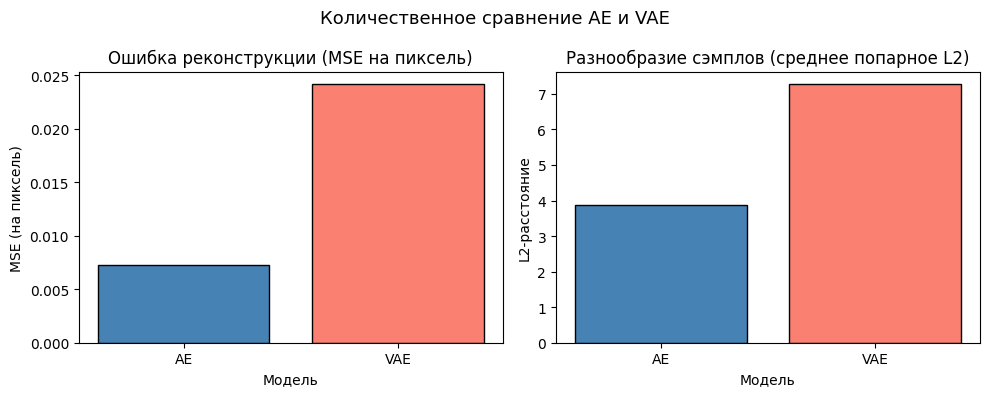

In [18]:
# Задача 9. Количественное сравнение AE и VAE

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

ae_model.eval()
vae_model.eval()

# ─── 1. Средняя ошибка реконструкции MSE на тестовой выборке ──────────────
ae_sq, vae_sq, n_pixels = 0.0, 0.0, 0

with torch.no_grad():
    for imgs, _ in test_loader:
        flat = imgs.view(imgs.size(0), -1).to(DEVICE)

        ae_recon_t = ae_model(flat)
        ae_sq += F.mse_loss(ae_recon_t, flat, reduction="sum").item()

        vae_recon_t, _, _ = vae_model(flat)
        vae_sq += F.mse_loss(vae_recon_t, flat, reduction="sum").item()

        n_pixels += imgs.size(0) * 784

ae_mse  = ae_sq  / n_pixels
vae_mse = vae_sq / n_pixels

print(f"Средняя MSE реконструкции (AE):  {ae_mse:.6f}")
print(f"Средняя MSE реконструкции (VAE): {vae_mse:.6f}")

# ─── 2. Разнообразие: среднее попарное L2-расстояние между 100 сэмплами ───
n_diversity = 100
torch.manual_seed(SEED)

z_vae_d = torch.randn(n_diversity, LATENT_DIM_VAE).to(DEVICE)
z_ae_d  = torch.randn(n_diversity, LATENT_DIM).to(DEVICE)

with torch.no_grad():
    vae_samples = vae_model.decode(z_vae_d).cpu()   # (100, 784)
    ae_samples  = ae_model.decoder(z_ae_d).cpu()    # (100, 784)


def mean_pairwise_l2(samples: torch.Tensor) -> float:
    """Среднее попарное L2-расстояние по верхнему треугольнику матрицы дистанций."""
    n = samples.size(0)
    diff = samples.unsqueeze(0) - samples.unsqueeze(1)   # (n, n, d)
    dists = diff.norm(dim=2)                              # (n, n)
    mask = torch.triu(torch.ones(n, n, dtype=torch.bool), diagonal=1)
    return dists[mask].mean().item()


diversity_ae  = mean_pairwise_l2(ae_samples)
diversity_vae = mean_pairwise_l2(vae_samples)

print(f"\nСреднее попарное расстояние между {n_diversity} сэмплами:")
print(f"  AE:  {diversity_ae:.6f}")
print(f"  VAE: {diversity_vae:.6f}")

# ─── Гистограммы сравнения ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Количественное сравнение AE и VAE", fontsize=13)

colors = ["steelblue", "salmon"]
labels_bar = ["AE", "VAE"]

axes[0].bar(labels_bar, [ae_mse, vae_mse], color=colors, edgecolor="black")
axes[0].set_title("Ошибка реконструкции (MSE на пиксель)")
axes[0].set_xlabel("Модель")
axes[0].set_ylabel("MSE (на пиксель)")

axes[1].bar(labels_bar, [diversity_ae, diversity_vae],
            color=colors, edgecolor="black")
axes[1].set_title("Разнообразие сэмплов (среднее попарное L2)")
axes[1].set_xlabel("Модель")
axes[1].set_ylabel("L2-расстояние")

plt.tight_layout()
plt.show()

**Интерпретация:**

На тестовой выборке AE получил MSE **0.0072** на пиксель, VAE - **0.0241**: VAE ошибается при реконструкции в 3.3 раза больше. По разнообразию генерации картина обратная: среднее попарное L2-расстояние между 100 случайными сэмплами составило **3.88** для AE и **7.26** для VAE - разрыв почти двукратный. Это прямое следствие ELBO: KL-штраф снижает точность восстановления, но делает латентное пространство заполненным и пригодным для генерации.

---

## Интерпретация результатов

В ходе домашнего задания мы увидели следующее:

- Обычный автоэнкодер хорошо восстанавливает входные изображения и дает низкую ошибку реконструкции,
  но его латентное пространство не имеет явной вероятностной структуры.
- Вариационный автоэнкодер вводит вероятностное латентное пространство и использует ELBO,
  чтобы одновременно учиться восстанавливать данные и упорядочивать скрытые представления.
- В визуальных сравнениях автоэнкодер дает более резкие реконструкции, тогда как VAE иногда сглаживает детали,
  но зато позволяет лучше интерполировать между объектами и легко генерировать новые примеры.
- Латентное пространство VAE оказывается более регулярным: интерполяции между точками выглядят плавно и осмысленно.
- При генерации из prior VAE естественным образом порождает правдоподобные объекты, в то время как AE
  при случайном выборе латентных векторов может выдавать менее реалистичные изображения.


## Выводы

1. Автоэнкодер - надежный инструмент для сжатия и реконструкции, но не полноценная вероятностная модель.
2. Вариационный автоэнкодер добавляет вероятностный слой и ELBO, что превращает его в генеративную модель,
   пригодную для порождения новых данных.
3. При сравнении на одной задаче AE выигрывает по точности реконструкции, но VAE выигрывает по структуре
   латентного пространства и возможностям генерации.
4. Выбор между AE и VAE зависит от цели: если важна точная реконструкция - используем AE; если нужны генерация
   и контролируемое латентное пространство - выбираем VAE.
5. На практике часто комбинируют идеи AE, VAE, GAN и диффузионных моделей, чтобы достичь баланса между
   качеством, стабильностью и выразительностью.
